In [ ]:
%pip install lightkurve oktopus

In [1]:
from lightkurve import search_targetpixelfile
pixelfile = search_targetpixelfile("KIC 8462852", quarter=16).download(quality_bitmask="hardest");

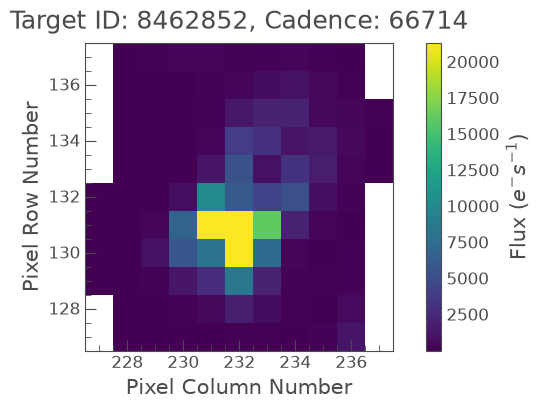

In [11]:
import matplotlib.pyplot as plt
pixelfile.plot(frame=1);
plt.show()

In [12]:
lc = pixelfile.to_lightcurve(aperture_mask="all");

In [19]:
lc.time, lc.flux

(<Time object: scale='tdb' format='bkjd' value=[1472.11777934 1472.13821223 1472.15864492 ... 1557.89718798 1557.9380561
  1557.95849016]>,
 <Quantity [258645.03, 258660.05, 258690.08, ..., 258929.86, 258884.66,
            258865.6 ] electron / s>)

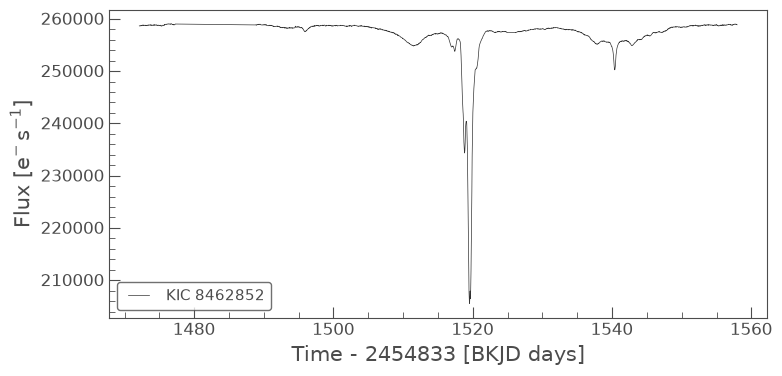

In [ ]:
lc.plot();
plt.show();

In [ ]:
pixelFile = search_targetpixelfile("KIC 6922244", quarter=4, cadence="long").download()

KeplerTargetPixelFile Object (ID: 6922244)

In [34]:
lc = pixelFile.to_lightcurve(aperture_mask=pixelFile.pipeline_mask)

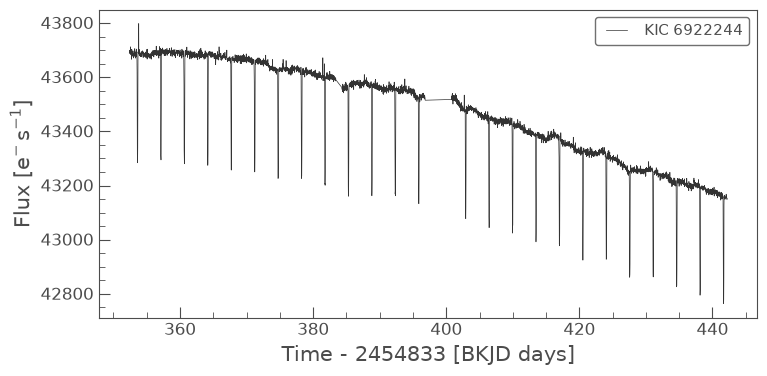

In [35]:
lc.plot();
plt.show();

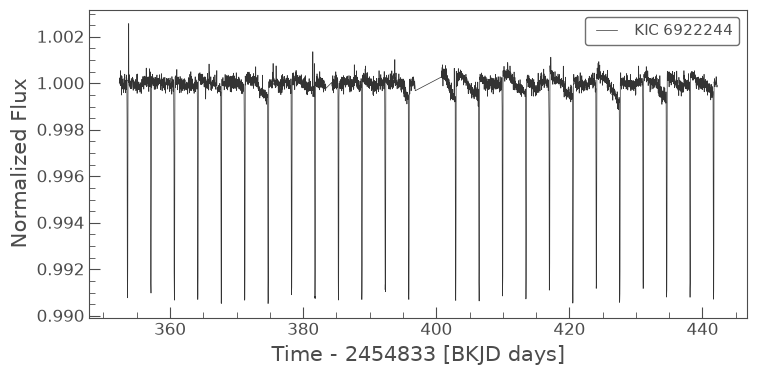

In [38]:
flat_lc = lc.flatten(window_length=401)
flat_lc.plot();
plt.show();

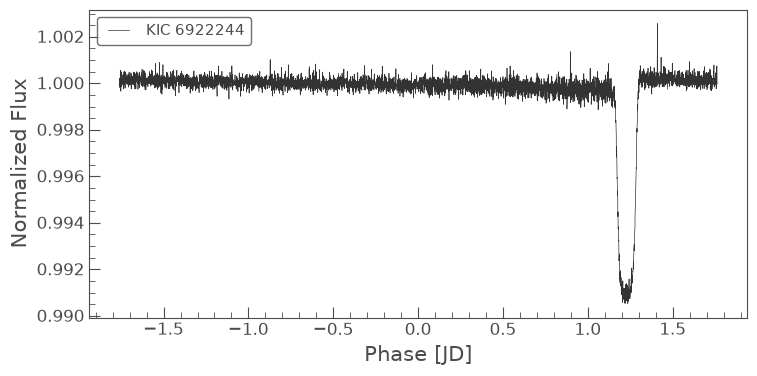

In [40]:
folded_lc = flat_lc.fold(period=3.5225)
folded_lc.plot()
plt.show()

c:\Users\sagar\prog\Exoplanet-detect\.venv\Lib\site-packages\lightkurve\lightcurve.py:3510: UserWarning: n_bins is no longer accepted for FoldedLightCurve objects. Please specify 'bins' instead
  warnings.warn(


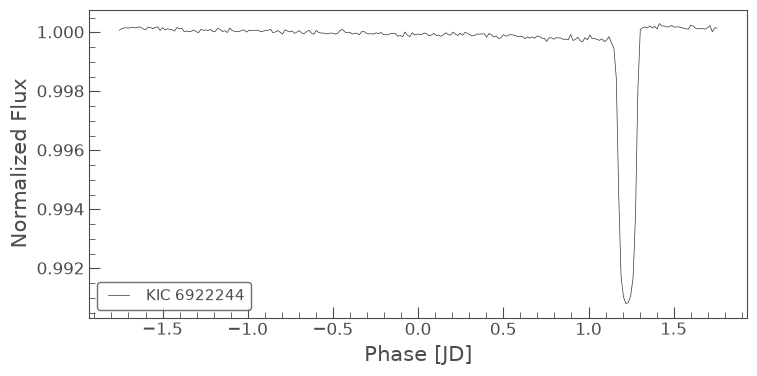

In [58]:
binned_lc = folded_lc.bin(n_bins=250)
binned_lc.plot()
plt.show();

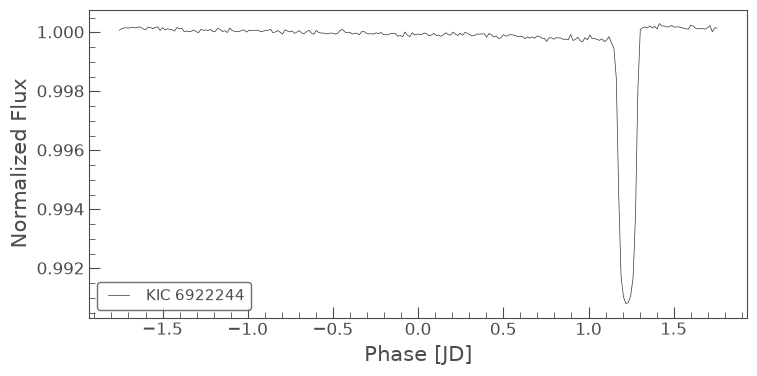

In [59]:
lc.remove_nans().flatten(window_length=401).fold(period=3.5225).bin(bins=250).plot()
plt.show()

`period` contains 130447 points.Periodogram is likely to be large, and slow to evaluate. Consider setting `frequency_factor` to a higher value.


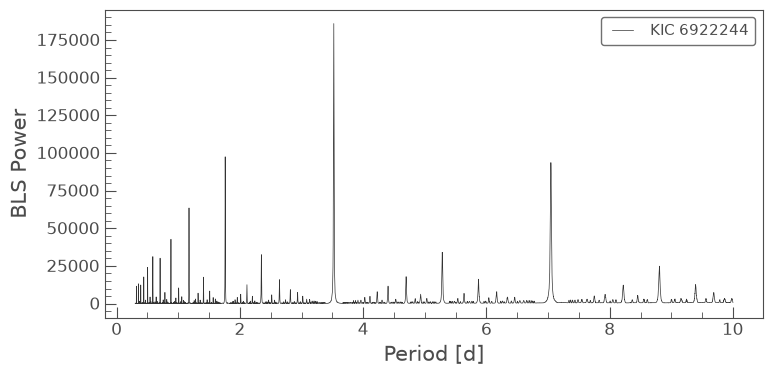

In [45]:
import numpy as np
periodogram = flat_lc.to_periodogram(method="bls", period=np.arange(0.3, 10, 0.001), duration=[0.02, 0.05, 0.1])
periodogram.plot()
plt.show();

In [49]:
best_fit_period = periodogram.period_at_max_power
print("Best fit period: {:.5f}".format(best_fit_period))

Best fit period: 3.52300 d


In [71]:
from lightkurve import search_targetpixelfile
search_result = search_targetpixelfile("Pi Mensae", mission="TESS", sector=1)
tpf = search_result.download(quality_bitmask="default");

c:\Users\sagar\prog\Exoplanet-detect\.venv\Lib\site-packages\lightkurve\search.py:421: LightkurveWarning: Warning: 2 files available to download. Only the first file has been downloaded. Please use `download_all()` or specify additional criteria (e.g. quarter, campaign, or sector) to limit your search.
  warnings.warn(


In [72]:
tpf.mission
tpf.targetid

261136679

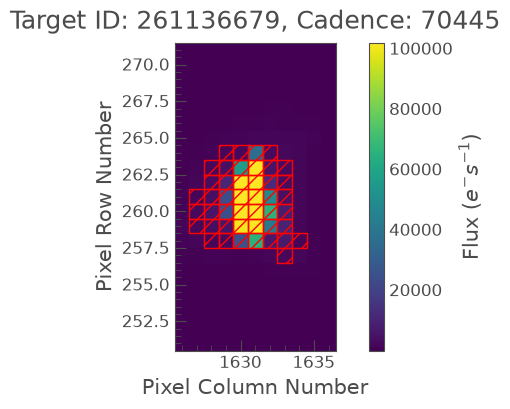

In [73]:
tpf.plot(aperture_mask=tpf.pipeline_mask);
plt.show();

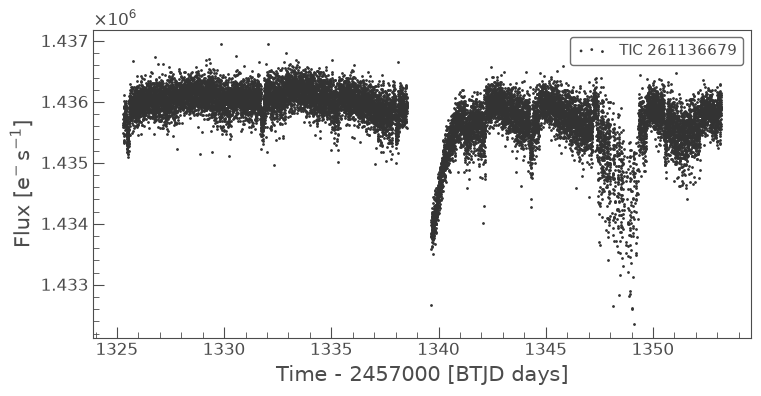

In [75]:
lc = tpf.to_lightcurve()
lc.scatter();
plt.show();

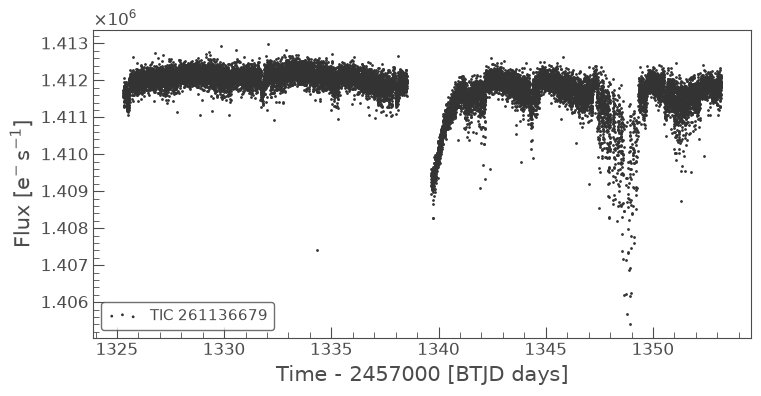

In [77]:
aperture_mask = tpf.create_threshold_mask(threshold=10)
lc = tpf.to_lightcurve(aperture_mask=aperture_mask)
lc.scatter()
plt.show();

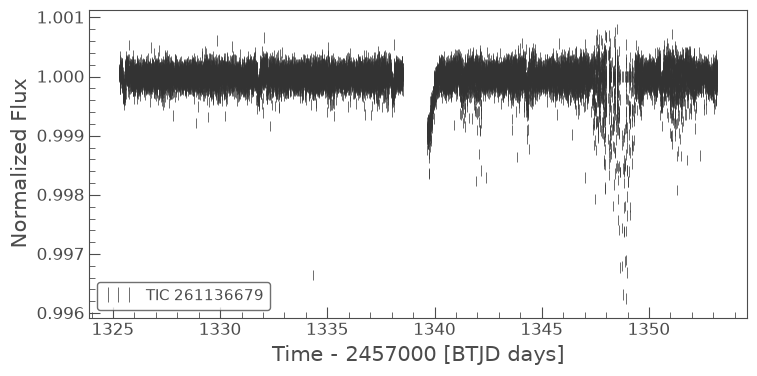

In [80]:
flat_lc = lc.flatten(window_length=1001)
flat_lc.errorbar();
plt.show();

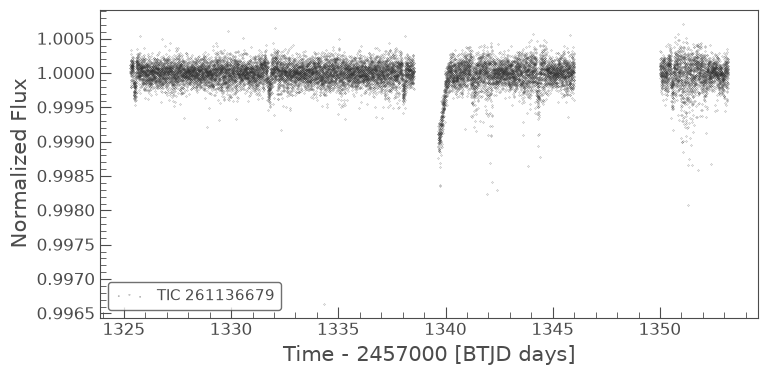

In [85]:
mask = (flat_lc.time.value < 1346) | (flat_lc.time.value > 1350)
masked_lc = flat_lc[mask]
masked_lc.scatter(s=0.1);
plt.show();

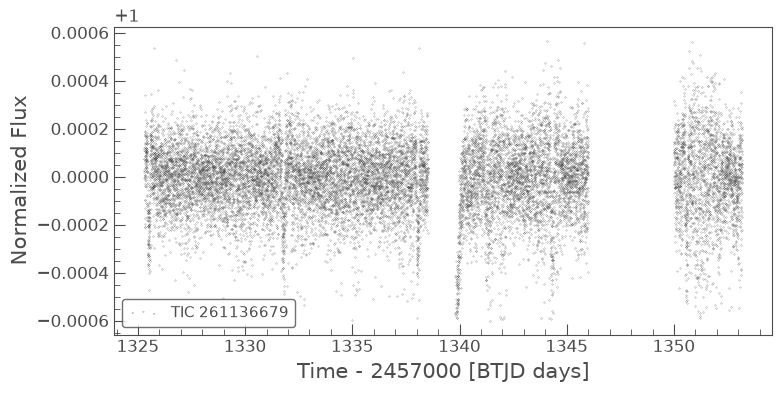

In [98]:
clipped_lc = masked_lc.remove_outliers(sigma=4)
clipped_lc.scatter(s=0.1);
plt.show()

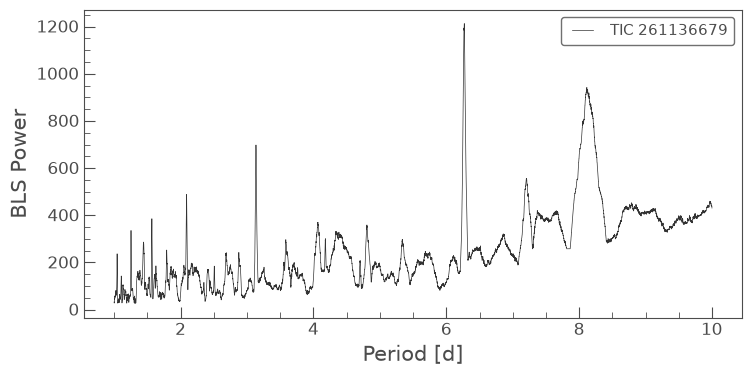

In [99]:
import numpy as np
periodogram = clipped_lc.to_periodogram(method="bls", period=np.arange(1, 10, 0.001))
periodogram.plot()
plt.show();

In [100]:
best_fit_period = periodogram.period_at_max_power
print("Best fit period: {:.3f}".format(best_fit_period))

Best fit period: 6.271 d


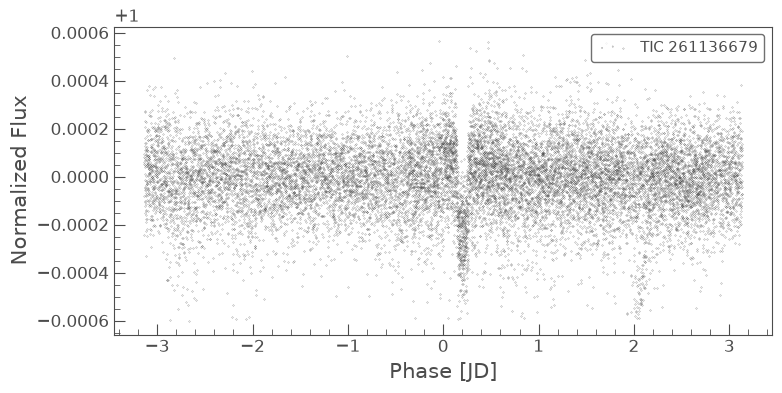

In [101]:
folded_lc = clipped_lc.fold(period=6.271)
folded_lc.scatter(s=0.1);
plt.show()

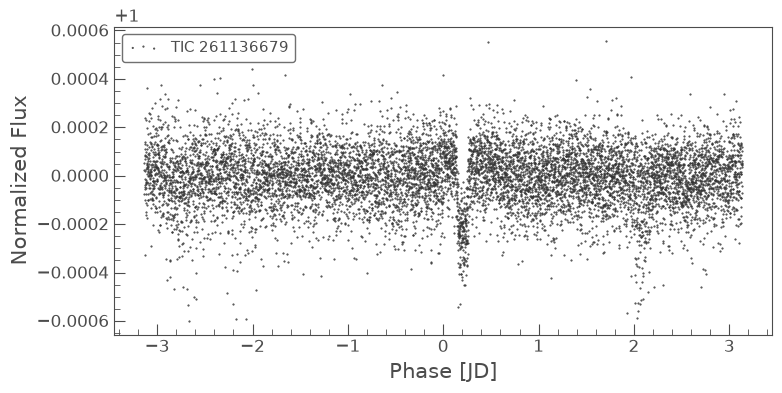

In [ ]:
binned_lc = folded_lc.bin(bins=10000 )
binned_lc.scatter(s=1);
plt.show();